# **Coding Time😈**

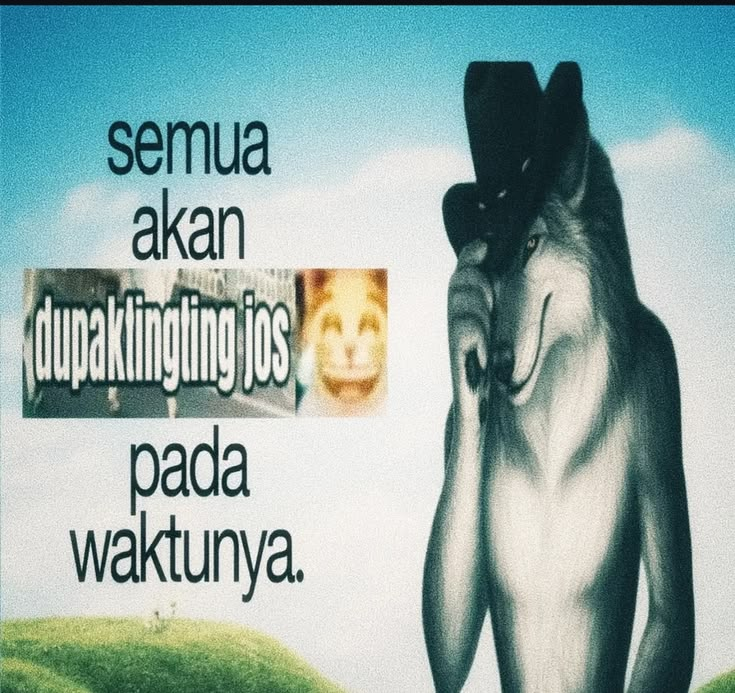


## 1. Jalur (Paths) dan Sub-jalur (Sub-paths)

Path adalah jalur yang dibentuk dari beberapa titik dan garis. Kita dapat membuat bentuk seperti segitiga menggunakan `move_to()`, `line_to()`, dan `close_path()`. Cairo juga menyediakan `curve_to()` untuk membuat kurva Bézier.

In [2]:

import cairo

WIDTH, HEIGHT = 400, 300
surface = cairo.ImageSurface(cairo.FORMAT_ARGB32, WIDTH, HEIGHT)
ctx = cairo.Context(surface)

# Background putih
ctx.set_source_rgb(1, 1, 1)
ctx.paint()

# Warna garis hitam
ctx.set_source_rgb(0, 0, 0)

# Segitiga
ctx.move_to(50, 50)
ctx.line_to(150, 50)
ctx.line_to(100, 100)
ctx.close_path()
ctx.stroke()

# Kurva Bezier
ctx.move_to(200, 50)
ctx.curve_to(220, 20, 280, 80, 300, 50)
ctx.stroke()

surface.write_to_png("paths.png")
print("Gambar disimpan: paths.png")


Gambar disimpan: paths.png


## 2. Garis dengan Panjang dan Sudut Tertentu

Posisi titik akhir sebuah garis dapat dihitung menggunakan trigonometri. Panjang garis dinyatakan dengan `r`, sedangkan sudut diubah ke radian menggunakan `math.radians()`.


In [3]:

import math
import cairo

WIDTH, HEIGHT = 400, 300
surface = cairo.ImageSurface(cairo.FORMAT_ARGB32, WIDTH, HEIGHT)
ctx = cairo.Context(surface)

ctx.set_source_rgb(1, 1, 1)
ctx.paint()
ctx.set_source_rgb(0, 0, 0)

# Titik awal
x1, y1 = 100, 150

# Panjang dan sudut garis
r = 150
a = math.radians(45)

# Menghitung titik akhir
x2 = x1 + r * math.cos(a)
y2 = y1 + r * math.sin(a)

# Garis dengan sudut 45 derajat
ctx.move_to(x1, y1)
ctx.line_to(x2, y2)

# Garis referensi horizontal
ctx.move_to(x1, y1)
ctx.line_to(x1 + r, y1)

# Garis referensi vertikal
ctx.move_to(x1, y1)
ctx.line_to(x1, y1 + r)

ctx.stroke()

surface.write_to_png("line_angle.png")
print("Gambar disimpan: line_angle.png")


Gambar disimpan: line_angle.png


**Penjelasan singkat:** Koordinat titik akhir dihitung dengan rumus `x2 = x1 + r*cos(a)` dan `y2 = y1 + r*sin(a)`. Konsep ini memungkinkan kita menggambar garis berdasarkan panjang dan sudut yang ditentukan.

## 3. Polygon

Polygon adalah bentuk yang tersusun dari beberapa garis lurus. Titik-titik polygon dibuat secara berurutan, kemudian path ditutup.

In [4]:

import cairo

WIDTH, HEIGHT = 400, 300
surface = cairo.ImageSurface(cairo.FORMAT_ARGB32, WIDTH, HEIGHT)
ctx = cairo.Context(surface)

ctx.set_source_rgb(1, 1, 1)
ctx.paint()

ctx.set_source_rgb(0, 0, 0)

# Membuat polygon
ctx.move_to(60, 60)
ctx.line_to(160, 40)
ctx.line_to(230, 100)
ctx.line_to(190, 180)
ctx.line_to(80, 170)
ctx.close_path()

ctx.stroke()

surface.write_to_png("polygon.png")
print("Gambar disimpan: polygon.png")


Gambar disimpan: polygon.png


**Penjelasan singkat:** Setiap `line_to()` menambahkan sisi polygon. `close_path()` menghubungkan titik terakhir kembali ke titik pertama sehingga bentuk menjadi tertutup.

## 4. Busur dengan Sudut

`arc()` digunakan untuk membuat busur lingkaran. Parameter utamanya adalah pusat `(cx, cy)`, radius, sudut awal, dan sudut akhir. Sudut pada Cairo menggunakan radian.

In [5]:

import math
import cairo

WIDTH, HEIGHT = 400, 300
surface = cairo.ImageSurface(cairo.FORMAT_ARGB32, WIDTH, HEIGHT)
ctx = cairo.Context(surface)

ctx.set_source_rgb(1, 1, 1)
ctx.paint()

ctx.set_source_rgb(0, 0, 0)

# Busur 180 derajat
ctx.arc(200, 150, 80, 0, math.pi)
ctx.stroke()

surface.write_to_png("arc.png")
print("Gambar disimpan: arc.png")


Gambar disimpan: arc.png


**Penjelasan singkat:** `math.pi` bernilai π radian atau 180°. Jadi `arc(200, 150, 80, 0, math.pi)` menghasilkan busur setengah lingkaran dengan pusat `(200,150)` dan radius 80.

## 5. Round Rectangle

Round rectangle adalah persegi panjang dengan sudut yang dibuat melengkung. Bentuk ini dapat dibuat dengan kombinasi `line_to()` dan `arc()`.

In [6]:

import math
import cairo

def draw_roundrect(ctx, x, y, width, height, r):
    ctx.move_to(x + r, y)
    ctx.line_to(x + width - r, y)
    ctx.arc(x + width - r, y + r, r, -math.pi / 2,0)
    ctx.line_to(x + width, y + height - r)
    ctx.arc(x + width - r, y + height - r, r, 0, math.pi / 2)
    ctx.line_to(x + r, y + height)
    ctx.arc(x + r, y + height - r, r, math.pi / 2, math.pi )
    ctx.line_to(x, y + r)
    ctx.arc( x + r, y + r, r, math.pi, -math.pi / 2)
    ctx.close_path()
    ctx.stroke()

WIDTH, HEIGHT = 400, 300
surface = cairo.ImageSurface(cairo.FORMAT_ARGB32, WIDTH, HEIGHT)
ctx = cairo.Context(surface)
ctx.set_source_rgb(1, 1, 1)
ctx.paint()
ctx.set_source_rgb(0, 0, 0)

# x, y, width, height, radius
draw_roundrect(ctx, 100, 80, 200, 120, 40)

surface.write_to_png("roundrect.png")
print("Gambar disimpan: roundrect.png")

Gambar disimpan: roundrect.png


**Penjelasan singkat:** Fungsi `draw_roundrect()` dibuat agar round rectangle dapat digunakan kembali. Parameter `r` menentukan besar lengkungan pada setiap sudut.

## 6. Kurva Fungsi

Kurva fungsi dapat dibuat dengan menghitung banyak titik `(x, y)`, kemudian menghubungkan titik-titik tersebut menggunakan garis. Contoh berikut menggunakan fungsi `y = e^(-x) sin(x)`.

In [7]:

import math
import cairo

WIDTH, HEIGHT = 600, 400
surface = cairo.ImageSurface(cairo.FORMAT_ARGB32, WIDTH, HEIGHT)
ctx = cairo.Context(surface)

ctx.set_source_rgb(1, 1, 1)
ctx.paint()

ctx.set_source_rgb(0, 0, 0)

x = 0
points = []

# Fungsi y = e^(-x) * sin(x)
while x < 5:
    y = math.exp(-x) * math.sin(x)

    # Konversi koordinat matematika ke koordinat canvas
    canvas_x = x * 100 + 50
    canvas_y = -y * 100 + 200

    points.append((canvas_x, canvas_y))

    x += 0.01

# Menggambar kurva
ctx.move_to(points[0][0], points[0][1])

for p in points[1:]:
    ctx.line_to(p[0], p[1])

ctx.stroke()

surface.write_to_png("function_curve.png")
print("Gambar disimpan: function_curve.png")


Gambar disimpan: function_curve.png


**Penjelasan singkat:** Program menghitung nilai fungsi pada banyak nilai `x`. Setiap hasil disimpan sebagai titik pada `points`, kemudian semua titik dihubungkan. Semakin kecil interval `x`, semakin halus kurva yang terlihat.

## 7. Menggabungkan Beberapa Objek Menjadi Objek Kompleks

Objek kompleks dapat dibuat dengan menggabungkan beberapa bentuk dasar. Contoh berikut menggabungkan **busur dan segitiga** menjadi satu bentuk.

In [8]:

import math
import cairo

WIDTH, HEIGHT = 400, 300
surface = cairo.ImageSurface(cairo.FORMAT_ARGB32, WIDTH, HEIGHT)
ctx = cairo.Context(surface)

ctx.set_source_rgb(1, 1, 1)
ctx.paint()

# Pusat dan radius busur
cx, cy = 200, 200
r = 100

# Sudut busur dari kiri ke kanan
a1 = math.pi
a2 = 0

# Titik puncak segitiga
peak_x = cx
peak_y = cy - 150

# Membuat sub-path baru
ctx.new_sub_path()

# Membuat alas berbentuk busur
ctx.arc(cx, cy, r, a1, a2)

# Mengambil titik ujung busur
x_left = cx + r * math.cos(a1)
y_left = cy + r * math.sin(a1)

x_right = cx + r * math.cos(a2)
y_right = cy + r * math.sin(a2)

# Membuat sisi segitiga
ctx.line_to(peak_x, peak_y)
ctx.line_to(x_left, y_left)

# Menutup bentuk
ctx.close_path()

# Mengisi bentuk
ctx.set_source_rgb(0.2, 0.6, 0.8)
ctx.fill()

surface.write_to_png("segitiga_dengan_busur.png")
print("Gambar disimpan: segitiga_dengan_busur.png")


Gambar disimpan: segitiga_dengan_busur.png


**Penjelasan singkat:** Contoh ini menunjukkan inti dari objek kompleks: beberapa bentuk dasar digabungkan menjadi satu path. Busur digunakan sebagai alas, kemudian dua garis menuju titik puncak membentuk segitiga. `fill()` mengisi seluruh bentuk yang sudah ditutup.


## Ringkasan

Pada materi ini, perintah Cairo yang paling penting adalah:

| Perintah | Fungsi |
|---|---|
| `move_to()` | Menentukan titik awal |
| `line_to()` | Membuat garis |
| `close_path()` | Menutup path |
| `new_sub_path()` | Memulai sub-path baru |
| `curve_to()` | Membuat kurva Bézier |
| `arc()` | Membuat busur/lingkaran |
| `stroke()` | Menggambar garis/outline |
| `fill()` | Mengisi bagian dalam objek |
| `rectangle()` | Membuat persegi panjang |
| `set_source_rgb()` | Menentukan warna |
| `set_line_width()` | Menentukan ketebalan garis |